# COLM Fiction Chunks — Qualitative Validation

Validates the 10 fiction novels fetched and chunked for the COLM norm extraction pipeline.
Checks: all books present, chunk sizes, metadata enrichment, first/last/middle chunk quality.

In [1]:
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv(os.path.join(os.path.dirname(os.getcwd()), '.env'))
CHUNKS_PATH = os.environ.get('FICTION_CHUNKS_PATH',
    '/share/pierson/matt/UAIR/outputs/2026-03-20_historical_norms/22-25-01/COLM_fetch_fiction/outputs/fetch/chunks.parquet')
df = pd.read_parquet(CHUNKS_PATH)
print(f'Loaded {len(df)} chunks from {CHUNKS_PATH}')
df.head(2)

Loaded 2993 chunks from /share/pierson/matt/UAIR/outputs/2026-03-20_historical_norms/23-05-10/COLM_fetch_fiction/outputs/fetch/chunks.parquet


,gutenberg_id,chunk_id,article_text,chunk_size,book_title,book_author,book_summary
0,1342,0,PRIDE.\n and\...,5632,Pride and Prejudice,Jane Austen,"In the early 19th century, during the Napoleon..."
1,1342,1,rable book. Although Miss Austen\nalways liked...,5461,Pride and Prejudice,Jane Austen,"In the early 19th century, during the Napoleon..."


## 1. Book inventory — are all 10 novels present?

In [2]:
EXPECTED_BOOKS = {
    '1342': 'Pride and Prejudice',
    '11': "Alice's Adventures in Wonderland",
    '145': 'Middlemarch',
    '541': 'The Age of Innocence',
    '1023': 'Bleak House',
    '135': 'Les Misérables',
    '1399': 'Anna Karenina',
    '4078': 'The Picture of Dorian Gray',
    '1184': 'The Count of Monte Cristo',
    '1984': 'Nineteen Eighty-Four',
}

summary = df.groupby('gutenberg_id').agg(
    chunks=('chunk_id', 'count'),
    title=('book_title', 'first'),
    author=('book_author', 'first'),
    avg_chunk_chars=('chunk_size', 'mean'),
    min_chunk_chars=('chunk_size', 'min'),
    max_chunk_chars=('chunk_size', 'max'),
    has_summary=('book_summary', lambda x: (x.astype(str) != '').all()),
).sort_values('chunks', ascending=False)

summary['avg_chunk_chars'] = summary['avg_chunk_chars'].round(0).astype(int)

present = set(df['gutenberg_id'].unique())
missing = set(EXPECTED_BOOKS.keys()) - present
if missing:
    print(f'⚠ MISSING BOOKS: {[EXPECTED_BOOKS[m] for m in missing]}')
else:
    print(f'✓ All {len(EXPECTED_BOOKS)} novels present')

print(f'Total chunks: {len(df):,}')
print()
summary

✓ All 10 novels present
Total chunks: 2,993



,chunks,title,author,avg_chunk_chars,min_chunk_chars,max_chunk_chars,has_summary
gutenberg_id,,,,,,,
135,706,Les Misérables,Victor Hugo,5564,1241,6736,True
1184,550,The Count of Monte Cristo,Alexandre Dumas,5772,3510,5997,True
1399,424,Anna Karenina,Leo Tolstoy,5631,1647,6376,True
1023,412,Bleak House,Charles Dickens,5704,3959,5997,True
145,393,Middlemarch,George Eliot,5526,2997,6099,True
1342,156,Pride and Prejudice,Jane Austen,5613,1908,5997,True
1984,133,Nineteen Eighty-Four,George Orwell,5412,2436,5994,True
541,123,The Age of Innocence,Edith Wharton,5693,3786,5995,True
4078,66,The Picture of Dorian Gray,Oscar Wilde,5521,2881,5995,True


## 2. Chunk size distribution

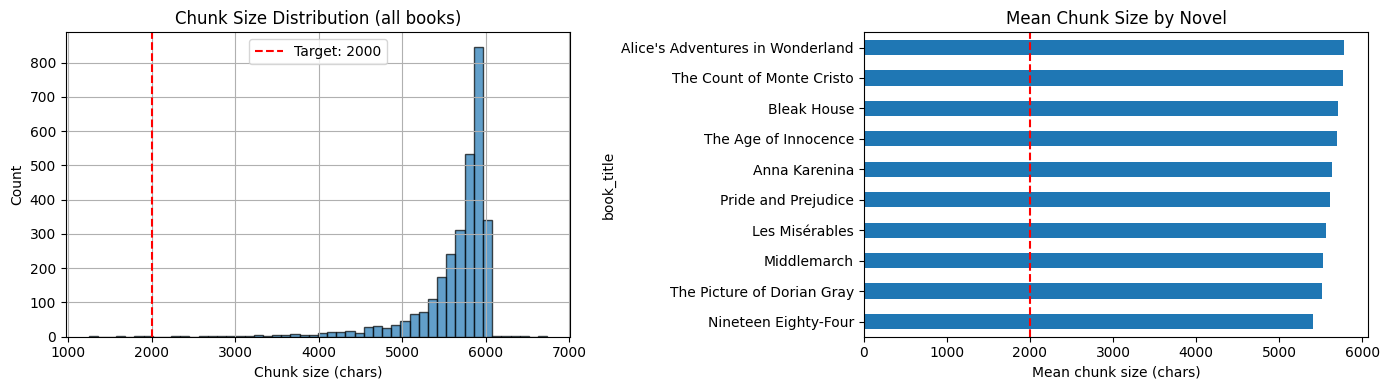

Chunk size stats: mean=5628, median=5795, min=1241, max=6736


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall distribution
df['chunk_size'].hist(bins=50, ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Chunk size (chars)')
axes[0].set_ylabel('Count')
axes[0].set_title('Chunk Size Distribution (all books)')
axes[0].axvline(2000, color='red', linestyle='--', label='Target: 2000')
axes[0].legend()

# Per-book
df.groupby('book_title')['chunk_size'].mean().sort_values().plot.barh(ax=axes[1])
axes[1].set_xlabel('Mean chunk size (chars)')
axes[1].set_title('Mean Chunk Size by Novel')
axes[1].axvline(2000, color='red', linestyle='--')

plt.tight_layout()
plt.show()

print(f'Chunk size stats: mean={df["chunk_size"].mean():.0f}, '
      f'median={df["chunk_size"].median():.0f}, '
      f'min={df["chunk_size"].min()}, max={df["chunk_size"].max()}')

## 3. Metadata enrichment — book titles, authors, summaries

In [4]:
for gid in sorted(df['gutenberg_id'].unique(), key=lambda x: df[df['gutenberg_id']==x]['book_title'].iloc[0]):
    row = df[df['gutenberg_id'] == gid].iloc[0]
    title = row['book_title']
    author = row['book_author']
    summary = str(row['book_summary'])
    n_chunks = len(df[df['gutenberg_id'] == gid])
    
    print(f'━━━ {title} by {author} (ID: {gid}, {n_chunks} chunks) ━━━')
    print(f'Summary ({len(summary.split())} words): {summary[:200]}...')
    print()

━━━ Alice's Adventures in Wonderland by Lewis Carroll (ID: 11, 30 chunks) ━━━
Summary (787 words): Sitting with her older sister on a bank, and feeling rather sleepy and bored, Alice suddenly spots a White Rabbit with a pocket watch and waistcoat hurrying by, lamenting that he is late. Surprised, A...

━━━ Anna Karenina by Leo Tolstoy (ID: 1399, 424 chunks) ━━━
Summary (258 words): Anna Karenina consists of more than the story of Anna Karenina, a married socialite, and her affair with the affluent Count Vronsky, though their relationship is a very strong component of the plot. T...

━━━ Bleak House by Charles Dickens (ID: 1023, 412 chunks) ━━━
Summary (970 words): Jarndyce and Jarndyce is an interminable probate case in the Court of Chancery concerning two or more wills and their beneficiaries. Lady Honoria Dedlock, the beneficiary of one of the wills, lives wi...

━━━ Les Misérables by Victor Hugo (ID: 135, 706 chunks) ━━━
Summary (3283 words): In 1815 Digne, the peasant Jean Valjean,

## 4. Qualitative chunk inspection — first, middle, last chunks per book

Verify that:
- First chunks contain opening text (not Gutenberg boilerplate)
- Middle chunks are coherent narrative passages
- Last chunks contain closing text (not Gutenberg license)

In [5]:
def show_chunk(row, label=''):
    text = row['article_text']
    print(f'  [{label}] chunk_id={row["chunk_id"]}, {len(text)} chars')
    print(f'  First 300 chars: {repr(text[:300])}')
    print(f'  Last  200 chars: {repr(text[-200:])}')
    print()

for gid in sorted(df['gutenberg_id'].unique(), key=lambda x: df[df['gutenberg_id']==x]['book_title'].iloc[0]):
    book = df[df['gutenberg_id'] == gid].sort_values('chunk_id')
    title = book.iloc[0]['book_title']
    print(f'\n{"═" * 70}')
    print(f'{title} ({len(book)} chunks)')
    print(f'{"═" * 70}')
    
    show_chunk(book.iloc[0], 'FIRST')
    mid = len(book) // 2
    show_chunk(book.iloc[mid], 'MIDDLE')
    show_chunk(book.iloc[-1], 'LAST')


══════════════════════════════════════════════════════════════════════
Alice's Adventures in Wonderland (30 chunks)
══════════════════════════════════════════════════════════════════════
  [FIRST] chunk_id=0, 5614 chars
  First 300 chars: 'Alice’s Adventures in Wonderland\n\nby Lewis Carroll\n\nTHE MILLENNIUM FULCRUM EDITION 3.0\n\nContents\n\nCHAPTER I.     Down the Rabbit-Hole\n CHAPTER II.    The Pool of Tears\n CHAPTER III.   A Caucus-Race and a Long Tale\n CHAPTER IV.    The Rabbit Sends in a Little Bill\n CHAPTER V.     Advice from a Caterp'
  Last  200 chars: 'inah, and saying to her very earnestly,\n“Now, Dinah, tell me the truth: did you ever eat a bat?” when suddenly,\nthump! thump! down she came upon a heap of sticks and dry leaves, and\nthe fall was over.'

  [MIDDLE] chunk_id=15, 5948 chars
  First 300 chars: 'cat! It’s the most curious thing I ever saw in my life!”\n\nShe had not gone much farther before she came in sight of the house of\nthe March Hare: she thought it m

## 5. Overlap verification

Check that consecutive chunks overlap (200 chars expected).

In [8]:
overlap_checks = []
for gid in df['gutenberg_id'].unique():
    book = df[df['gutenberg_id'] == gid].sort_values('chunk_id')
    texts = book['article_text'].tolist()
    overlaps = []
    for i in range(len(texts) - 1):
        # Check if the end of chunk i appears at the start of chunk i+1
        tail = texts[i][-1000:]
        overlap = 0
        for k in range(len(tail), 0, -1):
            if texts[i+1].startswith(tail[-k:]):
                overlap = k
                break
        overlaps.append(overlap)
    title = book.iloc[0]['book_title']
    if overlaps:
        avg = sum(overlaps) / len(overlaps)
        zeros = sum(1 for o in overlaps if o == 0)
        overlap_checks.append({'title': title, 'avg_overlap': round(avg), 'zero_overlaps': zeros, 'pairs': len(overlaps)})

ov_df = pd.DataFrame(overlap_checks).sort_values('title')
print('Overlap between consecutive chunks (expected ~200 chars):')
ov_df

Overlap between consecutive chunks (expected ~200 chars):


,title,avg_overlap,zero_overlaps,pairs
1,Alice's Adventures in Wonderland,1000,0,29
6,Anna Karenina,1000,0,423
4,Bleak House,1000,0,411
5,Les Misérables,1000,0,705
2,Middlemarch,1000,0,392
9,Nineteen Eighty-Four,1000,0,132
0,Pride and Prejudice,1000,0,155
3,The Age of Innocence,1000,0,122
8,The Count of Monte Cristo,1000,0,549
7,The Picture of Dorian Gray,1000,0,65


## 6. Prompt preview — what the LLM will see

Show the full user prompt for one sample chunk (book context + chunk text).

In [7]:
sample = df[df['book_title'] == 'Pride and Prejudice'].iloc[11]

# Reconstruct the prompt as _format_prompt would
title = sample['book_title']
author = sample['book_author']
summary = sample['book_summary']
article_text = sample['article_text']

book_context = f'Novel Context:\nThe text below is a short excerpt from the novel "{title}"'
book_context += f' by {author}'
book_context += (
    '. It is one of many consecutive chunks extracted from the full novel. '
    'The excerpt may begin or end mid-scene. Use the summary below to '
    'understand the broader societal context of the novel when identifying norms.\n'
)
book_context += f'\nNovel summary: {summary}\n\n---\n\n'

prompt = f'{book_context}Text from fiction:\n{article_text}'

print(f'Total prompt length: {len(prompt):,} chars ({len(prompt.split()):,} words)')
print(f'Book context: {len(book_context):,} chars')
print(f'Chunk text: {len(article_text):,} chars')
print()
print('=' * 70)
print('FULL PROMPT PREVIEW')
print('=' * 70)
print(prompt)

Total prompt length: 13,159 chars (2,234 words)
Book context: 7,996 chars
Chunk text: 5,144 chars

FULL PROMPT PREVIEW
Novel Context:
The text below is a short excerpt from the novel "Pride and Prejudice" by Jane Austen. It is one of many consecutive chunks extracted from the full novel. The excerpt may begin or end mid-scene. Use the summary below to understand the broader societal context of the novel when identifying norms.

Novel summary: In the early 19th century, during the Napoleonic Wars, the Bennet family lives at their Longbourn estate, situated near the small town of Meryton in Hertfordshire, England. Mrs Bennet's greatest desire is to marry off her five daughters to secure their futures. A regiment of militia is encamped outside the town, and the younger Bennet daughters flirt with the officers.
The arrival of Mr Bingley, a rich bachelor who rents the neighbouring Netherfield estate, gives her hope that one of her daughters might contract a marriage to their advantage, beca